In [1]:
import sys
sys.path.append("..")

In [2]:
import os
os.chdir("..")

In [3]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from dataloader import get_dataloader

In [4]:
# CUDA: Nvidia CUDA-enabled GPU
if torch.cuda.is_available():
    print("Using GPU")
    device = torch.device("cuda")

# MPS: Apple Silicon
elif torch.backends.mps.is_available():
    print("Using MPS")
    device = torch.device("mps")

# CPU(for my system: linux): 
else:
    print("Using CPU")
    device = torch.device("cpu")

Using CPU


In [5]:
print(os.getcwd())
print(os.path.exists("asl_letters_small_processed/letters.csv"))

/home/hiteshb/projects/mediapipe-project
True


In [6]:
batch_size = 32

train_loader = get_dataloader(
    dataset_name="asl_letters_small",
    partition="train",
    as_landmarks=True,
    batch_size=batch_size,
    shuffle=True
)

val_loader = get_dataloader(
    dataset_name="asl_letters_small",
    partition="val",
    as_landmarks=True,
    batch_size=batch_size,
    shuffle=False
)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791327459.045148   88227 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791327459.056862   88227 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791327459.073550   88234 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791327459.087297   88233 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
# Get a sample batch to understand data dimensions
for landmarks, labels in train_loader:
    print(f"Landmarks shape: {landmarks.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Sample landmark vector: {landmarks[0]}")
    print(f"Sample label: {labels[0]}")
    break

W0000 00:00:1791327461.590296   88228 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Landmarks shape: torch.Size([32, 42])
Labels shape: torch.Size([32])
Sample landmark vector: tensor([ 0.0000,  0.0000,  0.0792, -0.0401,  0.1428, -0.1035,  0.1274, -0.1790,
         0.0880, -0.2214,  0.1216, -0.2003,  0.1327, -0.2906,  0.1302, -0.3469,
         0.1236, -0.3942,  0.0739, -0.2155,  0.0856, -0.3134,  0.0860, -0.3759,
         0.0814, -0.4269,  0.0302, -0.2121,  0.0346, -0.3062,  0.0365, -0.3633,
         0.0345, -0.4098, -0.0183, -0.1938, -0.0161, -0.2676, -0.0109, -0.3117,
        -0.0071, -0.3510])
Sample label: 1


In [8]:
class AvB_Model(nn.Module):
    def __init__(self, input_features=42, num_classes=2):
        super(AvB_Model, self).__init__()  # Call superclass constructor
        
        # Define fully-connected layers
        self.fc1 = torch.nn.Linear(input_features, 256)
        self.fc2 = torch.nn.Linear(256, 128)
        self.fc3 = torch.nn.Linear(128, num_classes)

        # Define activation function
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        """Forward pass through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 42)
            
        Returns:
            Output logits of shape (batch_size, num_classes)
        """
        # First fully-connected layer + ReLU activation
        x = self.fc1(x)
        x = self.relu(x)

        # Second fully-connected layer + ReLU activation
        x = self.fc2(x)
        x = self.relu(x)

        # Output layer (no activation, will be used with CrossEntropyLoss)
        x = self.fc3(x)
        return x

In [9]:
# Initialize model, loss function, and optimizer
model = AvB_Model(input_features=42, num_classes=2)
model.to(device)

# CrossEntropyLoss combines softmax and negative log-likelihood
criterion = nn.CrossEntropyLoss()

#optimizer = optim.SGD(model.parameters(), lr=0.001)
# The Adam optimizer tends to converge much 
# more quickly with this dataset compared to 
# using Stochastic Gradient Descent
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model:\n{model}")

Model:
AvB_Model(
  (fc1): Linear(in_features=42, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


In [10]:
# Training parameters
num_epochs = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    epoch_train_correct = 0
    epoch_train_total = 0
    
    for landmarks, labels in train_loader:
        landmarks = landmarks.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()              # reset gradients
        outputs = model(landmarks)         # make a prediction using the model (forward pass)
        loss = criterion(outputs, labels)  # compare predictions to ground truth labels
        loss.backward()                    # calculate gradients (backward pass)
        optimizer.step()                   # update parameters
        
        # Track metrics
        epoch_train_loss += loss.item() * landmarks.size(0)
        _, predicted = torch.max(outputs, 1)
        epoch_train_correct += (predicted == labels).sum().item()
        epoch_train_total += labels.size(0)
    
    # Average training metrics for epoch
    avg_train_loss = epoch_train_loss / epoch_train_total
    avg_train_acc = epoch_train_correct / epoch_train_total
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    
    # set model to eval mode (no updating of weights)
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_correct = 0
    epoch_val_total = 0
    
    with torch.no_grad():
        # check performance on validation dataset
        for landmarks, labels in val_loader:
            landmarks = landmarks.to(device)
            labels = labels.to(device)
            
            outputs = model(landmarks)
            
            loss = criterion(outputs, labels)
            
            epoch_val_loss += loss.item() * landmarks.size(0)
            _, predicted = torch.max(outputs, 1)
            epoch_val_correct += (predicted == labels).sum().item()
            epoch_val_total += labels.size(0)
    
    # Average validation metrics for epoch
    avg_val_loss = epoch_val_loss / epoch_val_total
    avg_val_acc = epoch_val_correct / epoch_val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc*100:.2f}%")

save_path = "./AvB_fc_model.pth"
torch.save(model.state_dict(), save_path)
print(f"saved model to {save_path}: {val_accuracies[-1]:.2f}% accuracy")

Epoch [1/10] - Train Loss: 0.6250, Train Acc: 95.18% | Val Loss: 0.5315, Val Acc: 99.17%
Epoch [2/10] - Train Loss: 0.4033, Train Acc: 99.77% | Val Loss: 0.2353, Val Acc: 100.00%
Epoch [3/10] - Train Loss: 0.1309, Train Acc: 100.00% | Val Loss: 0.0492, Val Acc: 100.00%
Epoch [4/10] - Train Loss: 0.0261, Train Acc: 99.77% | Val Loss: 0.0109, Val Acc: 100.00%
Epoch [5/10] - Train Loss: 0.0091, Train Acc: 99.77% | Val Loss: 0.0051, Val Acc: 100.00%
Epoch [6/10] - Train Loss: 0.0057, Train Acc: 99.77% | Val Loss: 0.0037, Val Acc: 100.00%
Epoch [7/10] - Train Loss: 0.0045, Train Acc: 100.00% | Val Loss: 0.0029, Val Acc: 100.00%
Epoch [8/10] - Train Loss: 0.0037, Train Acc: 99.77% | Val Loss: 0.0023, Val Acc: 100.00%
Epoch [9/10] - Train Loss: 0.0031, Train Acc: 100.00% | Val Loss: 0.0022, Val Acc: 100.00%
Epoch [10/10] - Train Loss: 0.0026, Train Acc: 100.00% | Val Loss: 0.0018, Val Acc: 100.00%
saved model to ./AvB_fc_model.pth: 1.00% accuracy


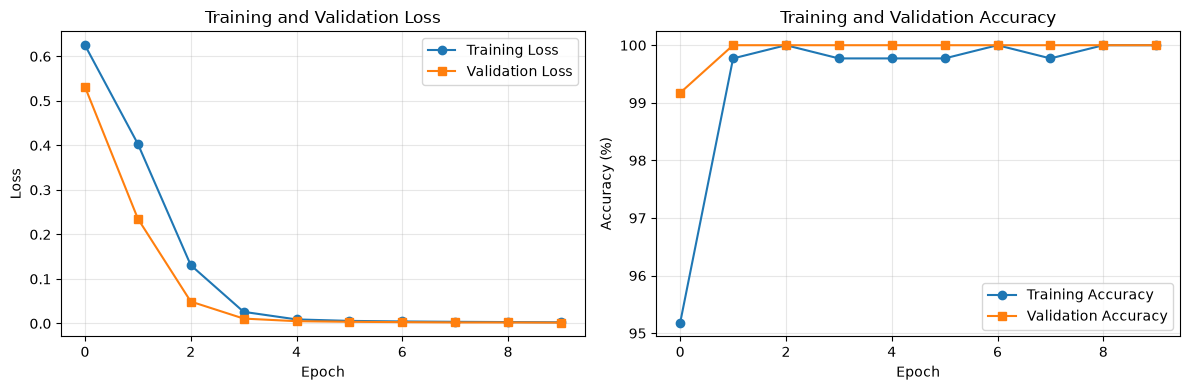


Final Results:
Training Accuracy: 100.00%
Validation Accuracy: 100.00%


In [11]:
# Plot training and validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
epochs_range = np.arange(len(train_losses))
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, np.array(train_accuracies) * 100, label='Training Accuracy', marker='o')
plt.plot(epochs_range, np.array(val_accuracies) * 100, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Training Accuracy: {train_accuracies[-1]*100:.2f}%")
print(f"Validation Accuracy: {val_accuracies[-1]*100:.2f}%")

In [12]:
import cv2
from dataloader import ImageToTensorPreprocessor, label_to_letter

model = AvB_Model()
model.load_state_dict(torch.load("AvB_fc_model.pth"))
model.to(device)
model.eval()

cap = cv2.VideoCapture(0)
find_hands = ImageToTensorPreprocessor(output_format="landmarks", static_image_mode=False)
while True:
    success, annotated_img = cap.read()
    annotated_img = cv2.flip(annotated_img, 1)
    key = cv2.waitKey(1) & 0xFF
    landmarks = find_hands(annotated_img)
    if landmarks is not None:
        landmarks = landmarks.to(device)
        classification = model(landmarks)
        predicted_label = torch.argmax(classification, dim=-1).item()
        predicted_letter = label_to_letter(predicted_label)
        confidence = torch.softmax(classification, dim=-1).max().item() * 100

        annotated_img = find_hands.draw_hand_landmarks(
            annotated_img,
            text = f"Predicted: {predicted_letter} ({confidence:.1f}%)"
        )
    cv2.imshow("Image", annotated_img)
    if key == ord("q"):
        break

W0000 00:00:1791327596.683295   88440 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791327596.694710   88440 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
QFontDatabase: Cannot find font directory /home/hiteshb/projects/mediapipe-project/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hiteshb/projects/mediapipe-project/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/hiteshb/projects/mediapipe-project/venv/lib/python3.14/site-packages/cv2/qt/fo